# Test Error vs. Training Set Size

This notebook loads all experiment summaries inside `Langevin_training/results_rebuttal` and visualizes how the test error varies with training set size for each homogeneity penalty weight.


In [6]:
from pathlib import Path
import json
import sys
import importlib.util
from typing import Optional

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd

# Import slim_plotters
def import_slim_plotters(slim_plotters_path: Optional[str] = None):
    """
    Try to import `slim_plotters` as a normal module. If that fails:
      - If slim_plotters_path is a directory, use <dir>/slim_plotters.py
      - If it's a file, import exactly that file.
    Returns: (apply, color, SciencePlotter, PlotStyle)
    """
    try:
        from slim_plotters import apply, color, SciencePlotter, PlotStyle
        return apply, color, SciencePlotter, PlotStyle
    except Exception:
        pass  # fallback below

    if slim_plotters_path is None:
        slim_plotters_path = "/home/goring/mean_field_langevin/plots_utils/slim_plotters.py"

    p = Path(slim_plotters_path).expanduser().resolve()
    if p.is_dir():
        p = p / "slim_plotters.py"
    if not p.exists():
        raise FileNotFoundError(f"slim_plotters.py not found at: {p}")

    # easiest: add its folder to sys.path then import
    sys.path.insert(0, str(p.parent))
    try:
        from slim_plotters import apply, color, SciencePlotter, PlotStyle
        return apply, color, SciencePlotter, PlotStyle
    except Exception:
        spec = importlib.util.spec_from_file_location("slim_plotters", str(p))
        if spec is None or spec.loader is None:
            raise ImportError(f"Could not load spec for: {p}")
        mod = importlib.util.module_from_spec(spec)
        spec.loader.exec_module(mod)
        sys.modules["slim_plotters"] = mod
        return mod.apply, mod.color, mod.SciencePlotter, mod.PlotStyle

# Import and apply slim_plotters
apply, color, SciencePlotter, PlotStyle = import_slim_plotters()
apply(theme="light")



In [7]:
BASE_DIR = Path("/home/goring/mean_field_langevin/Langevin_training/results_rebuttal")
records = []

for subdir in sorted(BASE_DIR.iterdir()):
    if not subdir.is_dir():
        continue

    hyper_path = subdir / "hyperparameters.json"
    results_path = subdir / "d35_k4" / "training_results.json"

    if not hyper_path.exists() or not results_path.exists():
        continue

    with hyper_path.open() as f:
        hyper = json.load(f)

    penalty = hyper.get("homogeneity_penalty_weight")

    with results_path.open() as f:
        runs = json.load(f)

    for entry in runs:
        train_mse = entry.get("train_mse")
        test_mse = entry.get("test_mse")

        if train_mse is None or test_mse is None:
            continue

        records.append(
            {
                "result_dir": subdir.name,
                "homogeneity_penalty_weight": penalty,
                "P": entry.get("P"),
                "exp_id": entry.get("exp_id"),
                "train_mse": train_mse,
                "test_mse": test_mse,
            }
        )

raw_df = pd.DataFrame(records)
raw_df.sort_values(["homogeneity_penalty_weight", "P", "exp_id"]).head()


,result_dir,homogeneity_penalty_weight,P,exp_id,train_mse,test_mse
9,d35_k4_h0,0.0,10,0,0.000401,1.481250
10,d35_k4_h0,0.0,10,1,0.000133,1.558576
11,d35_k4_h0,0.0,10,2,0.000340,1.537310
12,d35_k4_h0,0.0,100,0,0.003796,1.515250
13,d35_k4_h0,0.0,100,1,0.002593,1.598575


In [8]:
if raw_df.empty:
    raise ValueError("No training results were found under the specified directory.")

agg_df = (
    raw_df
    .groupby(["homogeneity_penalty_weight", "P"], as_index=False)
    .agg(
        test_mse_mean=("test_mse", "mean"),
        test_mse_std=("test_mse", "std"),
        num_runs=("test_mse", "size"),
    )
    .sort_values(["homogeneity_penalty_weight", "P"], ascending=[True, True])
)

# Calculate SEM (standard error of the mean) for error ribbons
agg_df["test_mse_sem"] = agg_df["test_mse_std"] / np.sqrt(agg_df["num_runs"])

agg_df


,homogeneity_penalty_weight,P,test_mse_mean,test_mse_std,num_runs,test_mse_sem
0,0.0,10,1.525712,0.039946,3,0.023063
1,0.0,100,1.542362,0.048692,3,0.028112
2,0.0,500,1.754411,0.044366,3,0.025615
3,0.0,750,0.130561,0.044284,3,0.025567
4,0.0,1000,0.058785,0.012015,3,0.006937
...,...,...,...,...,...,...
86,10.0,7500,1.036513,0.000550,3,0.000318
87,10.0,10000,1.021174,0.002679,3,0.001547
88,10.0,20000,1.008475,0.001068,3,0.000617
89,10.0,30000,1.005937,0.001239,3,0.000715


In [9]:
NNGP_DIR = Path("/home/goring/mean_field_langevin/MCMC_composite/results_reb/NNGPd35k4_long4")


def load_nngp_dataframe(base_dir: Path) -> pd.DataFrame:
    rows = []

    for json_path in sorted(base_dir.glob("*.json")):
        with json_path.open() as f:
            payload = json.load(f)

        summary = payload.get("summary", {})
        final_eval = summary.get("final_eval", {})

        train_size = summary.get("P_train") or summary.get("P")
        test_mse = final_eval.get("eval_mse_total")

        if train_size is None or test_mse is None:
            continue

        rows.append(
            {
                "P": train_size,
                "test_mse_mean": test_mse,
                "test_mse_std": 0.0,
                "result_file": json_path.name,
            }
        )

    if not rows:
        return pd.DataFrame(columns=["P", "test_mse_mean", "test_mse_std", "result_file"])

    return pd.DataFrame(rows).sort_values("P").reset_index(drop=True)


nngp_df = load_nngp_dataframe(NNGP_DIR)
nngp_df.head()


,P,test_mse_mean,test_mse_std,result_file
0,10,1.339619,0.0,nngp_relu_composite_P10_kap5.000e-03_M1_P10_Pe...
1,100,1.312417,0.0,nngp_relu_composite_P100_kap5.000e-03_M1_P100_...
2,500,2.012602,0.0,nngp_relu_composite_P500_kap5.000e-03_M1_P500_...
3,750,2.030859,0.0,nngp_relu_composite_P750_kap5.000e-03_M1_P750_...
4,1000,1.891488,0.0,nngp_relu_composite_P1000_kap5.000e-03_M1_P100...


Saved plot to: /home/goring/mean_field_langevin/Langevin_training/results_rebuttal/generalization_vs_penalty.pdf


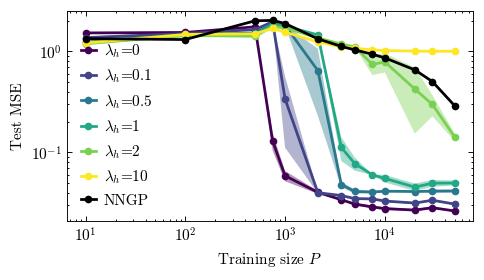

In [ ]:
# Get unique penalty values for viridis colormap (excluding 0.01)
penalty_values = sorted([p for p in agg_df["homogeneity_penalty_weight"].unique() if p != 0.01])
n_penalties = len(penalty_values)

# Create viridis colormap
try:
    # Modern matplotlib
    viridis = plt.colormaps['viridis']
except (AttributeError, KeyError):
    # Fallback for older matplotlib
    viridis = cm.get_cmap('viridis')
penalty_colors = {penalty: viridis(i / max(1, n_penalties - 1)) for i, penalty in enumerate(penalty_values)}

# Figure size matching fig1 style
fig_width = 4.5
aspect = 1.7
fig_h = fig_width / aspect
fig, ax = plt.subplots(figsize=(fig_width, fig_h))

# Plot ribbons for each penalty value (excluding 0.01)
for penalty, group in agg_df.groupby("homogeneity_penalty_weight"):
    # Skip penalty value 0.01
    if penalty == 0.01:
        continue
        
    group = group.sort_values("P")
    x = group["P"].values
    y_mean = group["test_mse_mean"].values
    y_sem = group["test_mse_sem"].fillna(0.0).values
    
    # Get color from viridis
    c = penalty_colors[penalty]
    
    # Plot ribbon (filled area) with high alpha
    ax.fill_between(
        x,
        y_mean - y_sem,
        y_mean + y_sem,
        alpha=0.4,
        color=c,
        edgecolor='none',
    )
    
    # Plot mean line
    ax.plot(
        x,
        y_mean,
        marker="o",
        linestyle="-",
        color=c,
        label=f"$\lambda_h$={penalty:g}",
        markersize=4.0,
        linewidth=1.8,
        zorder=3,
    )

# Plot NNGP in black
if not nngp_df.empty:
    nngp_sorted = nngp_df.sort_values("P")
    ax.plot(
        nngp_sorted["P"],
        nngp_sorted["test_mse_mean"],
        marker="o",
        linestyle="-",
        color="black",
        label="NNGP",
        markersize=4.0,
        linewidth=1.8,
        zorder=3,
    )

# Axes styling matching fig1
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Training size $P$")
ax.set_ylabel(r"Test MSE")

# Legend styling matching fig1
leg = ax.legend(loc="lower left", frameon=False)
if leg is not None:
    leg.set_title("")

# No grid, no title (matching fig1 style)
ax.grid(False)

plt.tight_layout()

# Save as PDF
output_path = Path("/home/goring/mean_field_langevin/Langevin_training/results_rebuttal/generalization_vs_penalty.pdf")
fig.savefig(output_path, format="pdf", bbox_inches="tight", dpi=300)
print(f"Saved plot to: {output_path}")

plt.show()

